## Final avaition and legal network - based on Elias's nb + Lowie's earlier work

Changes vs. Elias's networks: 

(1) legal network: 
- keywords based on the "ground truth" figures in email, people from whom it is publicly known that they have been involved in legal matters linked to esptein files. 
- "manual" verification of connections afterwards (fed to Claude) - to filter out connections picked via key words which appear not to actually be legal. (list Non_legal => these are filtered out). 
- NDA key words are currently part of legal key words. However, Elias had the idea to have this a separate element added to the network => could be nice. (recruitment network was another one he explored) 

(2) aviation network: 
- extension of Elias's aviation_actions list. Search via broader key words, then fed to Claude to elaborate a broader list of aviation_actions.
- no application of deduplication on doc id, as related_to edges linked to same document appeared to be - genuine different travel connections. 
- noise entities slightly expanded.

### PART 1: ACTUAL CELLS TO RUN 

In [33]:
# imports
from neo4j import GraphDatabase
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import networkx as nx
import scipy
from IPython.display import Image, display
import seaborn as sns

In [34]:
# connection to graph
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("", ""))

In [35]:
# creation of functions for easy Cypher running via VSC

def run_query(cypher):
    """Run a Cypher query and return results as a pandas DataFrame."""
    with driver.session() as session:
        result = session.run(cypher)
        return pd.DataFrame([dict(r) for r in result])

# Verify connection and confirm full import
counts = run_query("""
    MATCH (n) RETURN count(n) AS node_count
""")
edge_counts = run_query("""
    MATCH ()-[r]->() RETURN count(r) AS edge_count
""")
print(f"Connected to Memgraph.")
print(f"Nodes : {counts['node_count'][0]:,}  (expected 546,648)")
print(f"Edges : {edge_counts['edge_count'][0]:,}  (expected 1,432,277)")

Connected to Memgraph.
Nodes : 546,648  (expected 546,648)
Edges : 1,432,277  (expected 1,432,277)


In [36]:
# for use of python lists with Cypher
def to_cypher_list(lst):
    return '[' + ', '.join(f'"{item}"' for item in lst) + ']'

In [ ]:
## LISTS DEFIENED FOR ELABORATION AVIATON AND LEGAL NETWORKS

# (1) EPSTEIN NAMES - defining all names for epstein (all nodes we identified that represent Epstein)
EPSTEIN_NAMES = ["Jeffrey Epstein", "Jeff Epstein", "Epstein"]

# (2) LEGAL KEYWORDS
LEGAL_KEYWORDS = [
    # Criminal law
    'pleaded guilty',
    'indicted',
    'convicted',
    'sentenced',
    'arrested',
    'prosecuted',
    'charged',
    'prison sentence',
    'sex offender',
    'accused',
    # Non-prosecution
    'non-prosecution',
    'plea deal',
    'plea bargain',
    # Civil law
    'sued',
    'lawsuit',
    'filed suit',
    'filed complaint',
    'filed civil',
    'filed defamation',
    'filed claim',
    'filed federal',
    'civil action against',
    'defamation claim',
    'defamation action',
    'federal civil suit',
    'settled',
    # Procedural
    'subpoena',
    'deposition',
    'attempted to depose',
    'deposed',
    'filed motion',
    'filed counterclaim',
    'filed bar complaint',
    'filed allegations',
    'filed response',
    'introduce evidence',
    'exclusion of evidence',
    'argued before',
    # Testimonies
    'testimony',
    'testified before',
    'investigated',
    'accused',
    'questioned',
    # Fifth Amendment
    'fifth amendment',
    'self-incrimination',
    'took the fifth',
    # Immunity
    'granted immunity',
    'received immunity',
    'agreed not to prosecute',
]

# (3) NON LEGAL ACTIONS - actions caught by LEGAL_KEYWORDS but not actually legal
NON_LEGAL_ACTIONS = [
    'questioned belief about war',
    'questioned happiness of',
    'shared article about Glencore subpoena',
    'questioned interview coverage and mentioned Deutsche Bank papers',
    'shared legal news about lawsuit against',
    'questioned claim about',
    'questioned stance of',
    'questioned admissions by',
    'questioned motive of',
    'questioned need for face‑to‑face discussion with',
    'questioned why note is bad form',
    'questioned communication method',
    'questioned exit note',
    'issued',
    'initiated conversation with and questioned',
]

# (4) AVIATION ACTIONS
AVIATION_ACTIONS = [
    # Core travel with person
    'traveled with',
    'traveled_with',
    'travelled with',
    'accompanied',
    'accompanied by',
    'traveled to Little St James with',
    'traveled with to multiple residences',
    'traveled with on private plane',
    'traveled to Caribbean location with',
    'traveled to Europe with',
    'traveled extensively with',
    'traveled internationally with',
    'traveled internationally on private jet with',
    'traveled by private jet with',
    'traveled on private jet with',
    'traveled on private jet of',
    'traveled on private airplane with',
    'traveled on private plane with',
    'traveled on aircraft with',
    'traveled on jet owned by',
    'traveled on jet of',
    'traveled on flight with',
    'traveled on plane with',
    'traveled on planes in interstate commerce related to',
    'traveled aboard planes and boats of',
    'traveled via private jet of',
    'traveled via private aircraft with',
    'traveled on private aircraft owned by',
    'traveled on aircraft owned by',
    'traveled by helicopter provided by',
    # Flew variants
    'flew',
    'flew with',
    'flew_with',
    'flew on',
    'flew to',
    'flew on jet of',
    'flew on private jet of',
    'flew on private jet owned by',
    'flew on private jet to Africa',
    'flew on private jet',
    'flew on private plane of',
    'flew on airplane of',
    'flew on plane of',
    'flew on plane owned by',
    'flew on plane',
    'flew as passenger on',
    'flew to Africa',
    'flew to Africa with',
    'flew to South Africa with',
    'flew to and represented',
    'flew internationally with',
    'flew internationally to meet',
    'flew two young women to dinner to entertain',
    'flew with as passenger on aircraft owned by',
    'flew Gulfstream to',
    'flew with pilot',
    'allegedly flew',
    'allegedly flew victim to',
    'allegedly flew victims to',
    'allegedly flew to London',
    'allegedly flew for entertainment purposes to',
    # Transported variants
    'transported via private jet',
    'transported on private jet with',
    'transported via private aircraft as',
    'transported to Africa',
    'transported and sexually abused',
    'transported victim via',
    'transported victims via',
    'transported young girls via private aircraft with',
    'transported underage females across state lines using',
    'transported to various properties',
    'transported with',
    'transported to',
    'was transported via private jet by',
    'was transported to residence of',
    'allegedly transported for sexual purposes to',
    'allegedly transported and coerced',
    'allegedly transported victim with',
    'allegedly transported minors on',
    # Aircraft/jet specific
    'entertained on private jet',
    'hosted on private aircraft',
    'provided private jet travel to',
    'provided flights on jets to',
    'provided private jet to',
    'provided private jet for transport of',
    'provided private jet service to',
    'provided transportation via private jet to',
    'provided air transport to',
    'provided aircraft for travel with',
    'provided aircraft to',
    'offered transportation via private jet to',
    'offered jet ride to',
    'offered jet ride',
    'offered jet transport to',
    'offered jet charter to',
    'offered ride to Europe on jet',
    'invited to fly on private jet',
    'flew with as passenger on aircraft owned by',
    'boarded aircraft with',
    'arrived at private aircraft with',
    'ceased flying on aircraft with',
    'chartered private plane to transport guests to',
    'chartered private aircraft for',
    'used jet provided by',
    'used aircraft to transport to Africa',
    'operated Boeing aircraft with',
    'operated private airplane transporting',
    'began international travel with',
    'began traveling with',
    'traveled with Jeffrey Epstein',
    'hosted private jet flight for',
    'stepped away from royal jet and offered BBJ opportunity',
    # Flight log references
    'appears on flight logs with',
    'appeared in flight logs of',
    'appeared_in_flight_logs_of',
    'appeared on flight log with',
    'appeared on flight logs of',
    # Allegedly traveled
    'allegedly traveled with victim to',
    'allegedly arranged helicopter travel for',
    'allegedly instructed to travel and engage in sexual activity with',
    # Recruited and transported
    'recruited and transported to',
    'recruited and transported minors for',
    'recruited and transported girls to',
    'recruited and transported girls for',
    'recruited and transported underage girls for',
    'coordinated recruitment and transport to',
    # added after a second time feeding all actions to claude to verify answer
    'traveled with and attended to',
    'traveled internationally with and exploited for sex acts',
    'traveled to and exploited victims at',
    'traveled to and resided in',
    'traveled to during house arrest on',
    'traveled regularly with',
    'flew on private aircraft owned by',
    'transported on aircraft','hosted and transported to',
    'accepted air travel from',
    'accepted air transportation from',
    'directed to travel to and provide sexual services at',
    'directed to travel to island',
]

# (5) NOISE TERMS
NOISE_TERMS = [
    'jet', 'plane', 'aircraft', 'helicopter', 'island', 'ranch', 'apartment',
    'conference', 'driver', 'therapist',
    'real estate', 'property', 'NU', "victims' rights",'London',
    'multiple properties',
    'sexual assaults',
    'dinner event',
    'modeling agency',
]

In [38]:
# Building of Aviation network 
## step 1 - raw aviation network
df_aviation = run_query(f"""
MATCH (epstein:Entity)-[r:RELATED_TO]-(other:Entity)
WHERE epstein.name IN {to_cypher_list(EPSTEIN_NAMES)}
AND r.action IN {to_cypher_list(AVIATION_ACTIONS)}
WITH other, r, id(r) AS edge_id
WITH other,
     count(DISTINCT edge_id) AS connection_count,
     collect(DISTINCT r.action)[0..5] AS actions_used
RETURN other.name AS entity,
       other.entity_type AS entity_type,
       connection_count,
       actions_used
ORDER BY connection_count DESC
""")
print(f"Total entities: {len(df_aviation)}")
# print(df_aviation.to_string())

Total entities: 92


In [39]:
## step 2 - aviation network: removal of noise entities from aviation network
def is_noise_entity(name):
    if name is None:
        return True
    name_lower = name.lower()
    return any(term.lower() in name_lower for term in NOISE_TERMS)

aviation_clean = df_aviation[
    ~df_aviation['entity'].apply(is_noise_entity)
].reset_index(drop=True)

print(f"Before noise filter: {len(df_aviation)}")
print(f"After noise filter: {len(aviation_clean)}")
# print(aviation_clean.to_string())

Before noise filter: 92
After noise filter: 69


In [40]:
## step 3 - aviation network: consolidation of double entities in aviation network
ENTITY_CONSOLIDATION = {
    # Bill Clinton
    'President Clinton': 'Bill Clinton',
    # Alan Dershowitz
    'Professor Dershowitz': 'Alan M. Dershowitz',
    'Alan Dershowitz and Tatiana': 'Alan M. Dershowitz',
    # Lawrence Summers
    'Lawrence Henry Summers': 'Lawrence Summers',
    # Andrés Pastrana
    'Andrés Pastrana': 'Andrés Pastrana Arango',
    # Virginia Giuffre
    'Virginia L. Giuffre': 'Virginia Roberts Giuffre',
    'Virginia': 'Virginia Roberts Giuffre',
    # Thorbjørn Jagland
    'Thorbjorn Jagland': 'Thorbjørn Jagland',
    # Jean-Luc Brunel
    'Jean Luc Brunel': 'Jean-Luc Didier Henri-Rene Brunel',
}

def consolidate_entity(name):
    return ENTITY_CONSOLIDATION.get(name, name)

aviation_clean['entity_consolidated'] = aviation_clean['entity'].apply(consolidate_entity)

# aggregation per consolidated entity
aviation_consolidated = aviation_clean.groupby('entity_consolidated').agg(
    connection_count=('connection_count', 'sum'),
    entity_type=('entity_type', 'first'),
).reset_index().rename(columns={'entity_consolidated': 'entity'})

aviation_consolidated = aviation_consolidated.sort_values('connection_count', ascending=False).reset_index(drop=True)

print(f"Before consolidation: {len(aviation_clean)}")
print(f"After consolidation: {len(aviation_consolidated)}")
# print(aviation_consolidated.to_string())

Before consolidation: 69
After consolidation: 60


In [41]:
# Building Legal Network on top of Aviation Network
legal_where = ' OR '.join([
    f"toLower(replace(r.action, '_', ' ')) CONTAINS '{kw}'"
    for kw in LEGAL_KEYWORDS
])

non_legal_where = ' AND NOT (' + ' OR '.join([
    f"toLower(trim(replace(r.action, '_', ' '))) = '{action.lower().strip()}'"
    for action in NON_LEGAL_ACTIONS
]) + ')'

legal_where_filtered = '(' + ' OR '.join([
    f"toLower(trim(replace(r.action, '_', ' '))) CONTAINS '{kw}'"
    for kw in LEGAL_KEYWORDS
]) + ')' + non_legal_where

aviation_entities_consolidated = aviation_consolidated['entity'].tolist()

df_legal = run_query(f"""
MATCH (entity:Entity)-[r:RELATED_TO]-(other:Entity)
WHERE entity.name IN {to_cypher_list(aviation_entities_consolidated)}
AND ({legal_where_filtered})
RETURN entity.name AS entity,
       count(r) AS legal_count,
       collect(DISTINCT r.action)[0..5] AS legal_actions_sample
ORDER BY legal_count DESC
""")

# print(df_legal)

In [42]:
# Bridge nodes

bridge_nodes = aviation_consolidated.merge(
    df_legal,
    on='entity',
    how='left'
).fillna(0)

bridge_nodes['legal_count'] = bridge_nodes['legal_count'].astype(int)
bridge_nodes['total'] = bridge_nodes['connection_count'] + bridge_nodes['legal_count']
bridge_nodes = bridge_nodes.sort_values('total', ascending=False).reset_index(drop=True)

print(f"Total entities with legal connections: {len(df_legal)}")
print(bridge_nodes[['entity', 'connection_count', 'legal_count', 'total']].to_string())

Total entities with legal connections: 27
                                                                            entity  connection_count  legal_count  total
0                                                                 unknown person A                 6          310    316
1                                                               Alan M. Dershowitz                14          271    285
2                                                         Virginia Roberts Giuffre                19          136    155
3                                                                Ghislaine Maxwell                14          139    153
4                                                                     Bill Clinton               100           27    127
5                                                                     Donald Trump                 3          100    103
6                                                      Prince Andrew, Duke of York                 8           

In [52]:
# Extraction subgraph to NetworkX to calculate sociometrics

# extraction aviation network - all edges (with epstein or between other nodes)
aviation_entity_list = aviation_consolidated['entity'].tolist()

df_edges_aviation = run_query(f"""
MATCH (a:Entity)-[r:RELATED_TO]-(b:Entity)
WHERE a.name IN {to_cypher_list(aviation_entity_list)}
AND b.name IN {to_cypher_list(aviation_entity_list)}
AND r.action IN {to_cypher_list(AVIATION_ACTIONS)}
RETURN a.name AS source, b.name AS target, r.action AS action, 'aviation' AS edge_type
""")

# extraction of legal network - between nodes which are not epstein
df_edges_legal = run_query(f"""
MATCH (a:Entity)-[r:RELATED_TO]-(b:Entity)
WHERE a.name IN {to_cypher_list(aviation_entity_list)}
AND b.name IN {to_cypher_list(aviation_entity_list)}
AND ({legal_where_filtered})
RETURN a.name AS source, b.name AS target, r.action AS action, 'legal' AS edge_type
""")

# extraction of legal connections between Epstein and aviation entities 
# (extracted separately as espstein is exported separately as central node)
df_epstein_legal_edges = run_query(f"""
MATCH (epstein:Entity)-[r:RELATED_TO]-(other:Entity)
WHERE epstein.name IN {to_cypher_list(EPSTEIN_NAMES)}
AND other.name IN {to_cypher_list(aviation_entities_consolidated)}
AND ({legal_where_filtered})
RETURN epstein.name AS source, other.name AS target, r.action AS action, 'legal' AS edge_type
""")

print(f"Aviation edges between network entities incl. epstein: {len(df_edges_aviation)}")
print(f"Legal edges between network entities: {len(df_edges_legal)}")
print(f"Epstein legal edges: {len(df_epstein_legal_edges)}")

Aviation edges between network entities incl. epstein: 52
Legal edges between network entities: 189
Epstein legal edges: 199


In [53]:
# Building NetworkX: 

# combining all edges
df_all_edges = pd.concat([df_edges_aviation, df_edges_legal, df_epstein_legal_edges], ignore_index=True)

# Adding Epstein as central node
epstein_aviation_edges = aviation_consolidated[['entity', 'connection_count']].copy()
epstein_aviation_edges['source'] = 'Jeffrey Epstein'
epstein_aviation_edges['target'] = epstein_aviation_edges['entity']
epstein_aviation_edges['edge_type'] = 'aviation'
epstein_aviation_edges['weight'] = epstein_aviation_edges['connection_count']

# Building of weighted graph
G = nx.Graph()

# Adding of Epstein edges
for _, row in epstein_aviation_edges.iterrows():
    G.add_edge(row['source'], row['target'], 
               weight=row['weight'], 
               edge_type='aviation')

# Adding other edges (weighted by frequence)
for (src, tgt), group in df_all_edges.groupby(['source', 'target']):
    weight = len(group)
    edge_type = group['edge_type'].iloc[0]
    if G.has_edge(src, tgt):
        G[src][tgt]['weight'] += weight
    else:
        G.add_edge(src, tgt, weight=weight, edge_type=edge_type)

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

# Centrality metrics
degree_cent = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G, weight='weight')
closeness_cent = nx.closeness_centrality(G, distance='weight')
pagerank = nx.pagerank(G, weight='weight')

# Summarizing in DF
df_centrality = pd.DataFrame({
    'entity': list(degree_cent.keys()),
    'degree_centrality': list(degree_cent.values()),
    'betweenness_centrality': list(betweenness_cent.values()),
    'closeness_centrality': list(closeness_cent.values()),
    'pagerank': list(pagerank.values()),
}).sort_values('betweenness_centrality', ascending=False).reset_index(drop=True)

print(df_centrality.head(200).to_string())

Nodes: 61
Edges: 84
                                                                            entity  degree_centrality  betweenness_centrality  closeness_centrality  pagerank
0                                                                  Jeffrey Epstein           1.000000                0.959040              0.322581  0.334993
1                                                                 Adriana Mucinska           0.050000                0.124011              0.256410  0.007153
2                                                                 Nadia Marcinkova           0.050000                0.118079              0.137931  0.009358
3                                                      Prince Andrew, Duke of York           0.066667                0.090395              0.110906  0.016506
4                                                               Alan M. Dershowitz           0.150000                0.051130              0.182371  0.068252
5                               

In [54]:
# Adding column "Category" to entity nodes: 
# (to provide color codes for who is included in legal network vs who is only included in aviation network in Gephi)

# creation of df_nodes, which will be the one to be exported to csv for Gephi - starting from copy of df_centrality 
df_nodes = df_centrality.copy()

# Merging with bridge nodes
df_nodes = df_nodes.merge(
    bridge_nodes[['entity', 'connection_count', 'legal_count', 'total']],
    on='entity', how='left'
).fillna(0)

df_nodes['legal_count'] = df_nodes['legal_count'].astype(int)
df_nodes['connection_count'] = df_nodes['connection_count'].astype(int)

# defining categories (added as feature to entities): epstein, bridge (legal&aviation), aviation only, other: 
def categorize(row):
    if row['entity'] == 'Jeffrey Epstein':
        return 'epstein'
    elif row['connection_count'] > 0 and row['legal_count'] > 0:
        return 'bridge'
    elif row['connection_count'] > 0 and row['legal_count'] == 0:
        return 'aviation_only'
    else:
        return 'other'

df_nodes['category'] = df_nodes.apply(categorize, axis=1)

# actual exporting of CSV file for Gephi
# exporting nodes
df_nodes_gephi = df_nodes.copy()
df_nodes_gephi.insert(0, 'Id', df_nodes_gephi['entity'])
df_nodes_gephi.to_csv('nodes.csv', index=False)
print(df_nodes_gephi.head(3).to_string())
print(f"Nodes exported: {len(df_nodes)}")

# exporting edges
df_edges_export = df_all_edges.groupby(['source', 'target', 'edge_type']).size().reset_index(name='weight')

# Adding of aviation edges epstein to entities
epstein_edges = aviation_consolidated[['entity', 'connection_count']].copy()
epstein_edges.columns = ['target', 'weight']
epstein_edges['source'] = 'Jeffrey Epstein'
epstein_edges['edge_type'] = 'aviation'
df_edges_export = pd.concat([df_edges_export, epstein_edges], ignore_index=True)

df_edges_export_gephi = df_edges_export.rename(columns={
    'source': 'Source',
    'target': 'Target',
    'edge_type': 'edge_type',
    'weight': 'Weight'
})

# adding Type column to edges: 
df_edges_export_gephi['Type'] = 'Undirected'

df_edges_export_gephi.to_csv('edges.csv', index=False)

                 Id            entity  degree_centrality  betweenness_centrality  closeness_centrality  pagerank  connection_count  legal_count  total category
0   Jeffrey Epstein   Jeffrey Epstein               1.00                0.959040              0.322581  0.334993                 0            0    0.0  epstein
1  Adriana Mucinska  Adriana Mucinska               0.05                0.124011              0.256410  0.007153                 1            1    2.0   bridge
2  Nadia Marcinkova  Nadia Marcinkova               0.05                0.118079              0.137931  0.009358                 1           20   21.0   bridge
Nodes exported: 61


### (2) PART 2: GEPHI PNG OF NETWORKS + Extra plots for reporting - based on Elias's plots: 

explanation colors: 
- nodes: orange = legal + aviation; purple = only aviation; green = epstein, central node
- edges: pink = aviation connection; green = legal connection

Nodes: 
- inclusion of nodes = determined by the connection of the entities to related_to edges with actions in aviation_actions list and with one of the nodes representing Epstein as either source or target node. 
- bridge nodes = included nodes in aviation network, which are linked to related_to edges with actions that are found via search with legal_keyword list. These legal related_to edges are not necessarily only with Epstein himself, can be between other nodes in network. (e.g. many between Maxwell and Giuffre). 

Edges: 
- in the visualization of network, all related_to edges explained above in nodes have been included. And as well: for better calculation of centrality measures in network: travel connections (with same aviation_actions) between nodes different than Epstein. 
- edges are displayed in network layout by weight (amount of connections). weights of all edges have been rescaled on same 0.4 to 8 scale (both legal and aviation), for clarity purposes in the visual layout of the graph (else a big pink ball, because of loads of aviation connections around epstein).

NOTE: ALL THESE ELEMENTS CAN BE EASILY ADAPTED IN GEPHI FILE. 

Possible as well to add an extra column, e.g. to add timestamps of the related_to edges to add the dimension before/after 2008 esptein guilt plea deal. (note: only half of the edges seem to have a time stamp)

#### PNG's GEPHI Graph of full aviation + legal network 
8 png's in total: 
- size of nodes + node labels based on: (1) degree, (2) betweenness, (3) pagerank, (4) closeness (latter = less interesting for our network) 
- For each of these: one png with and one without labels. 

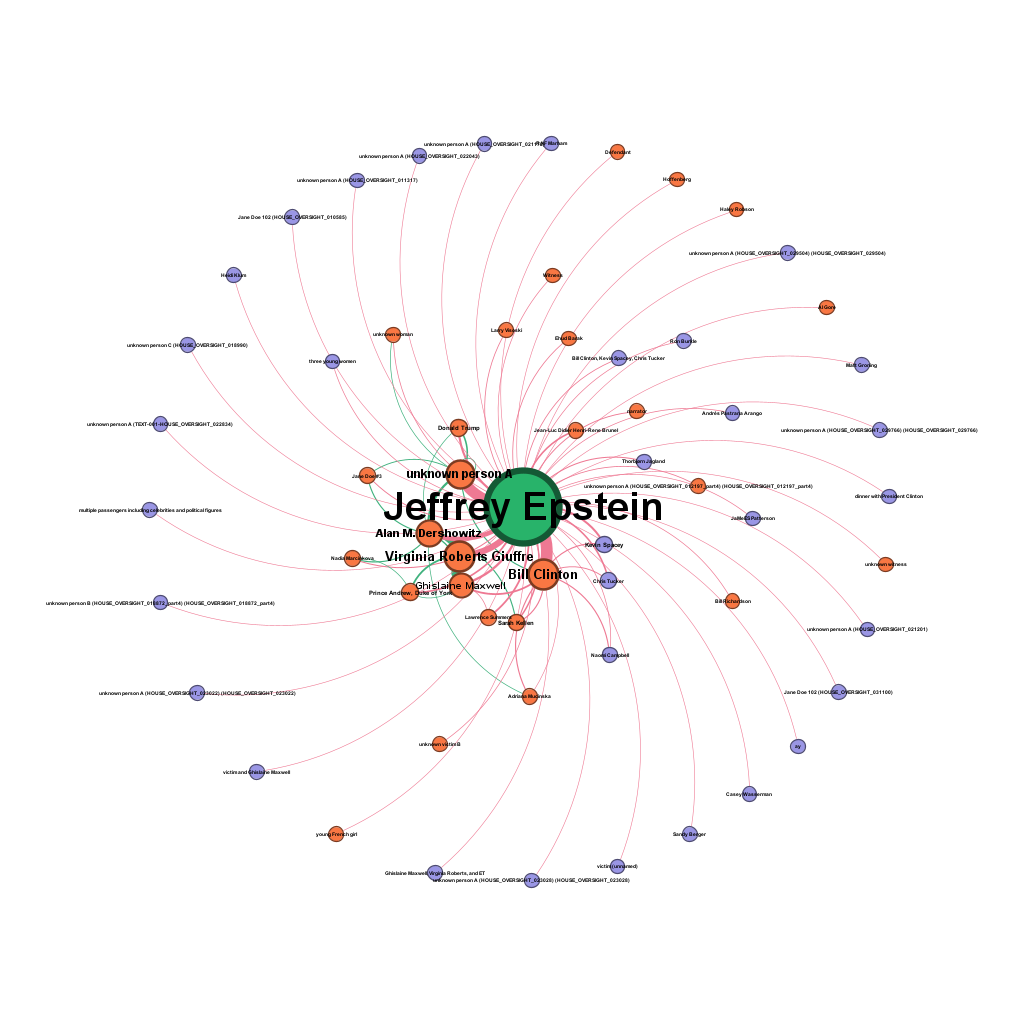

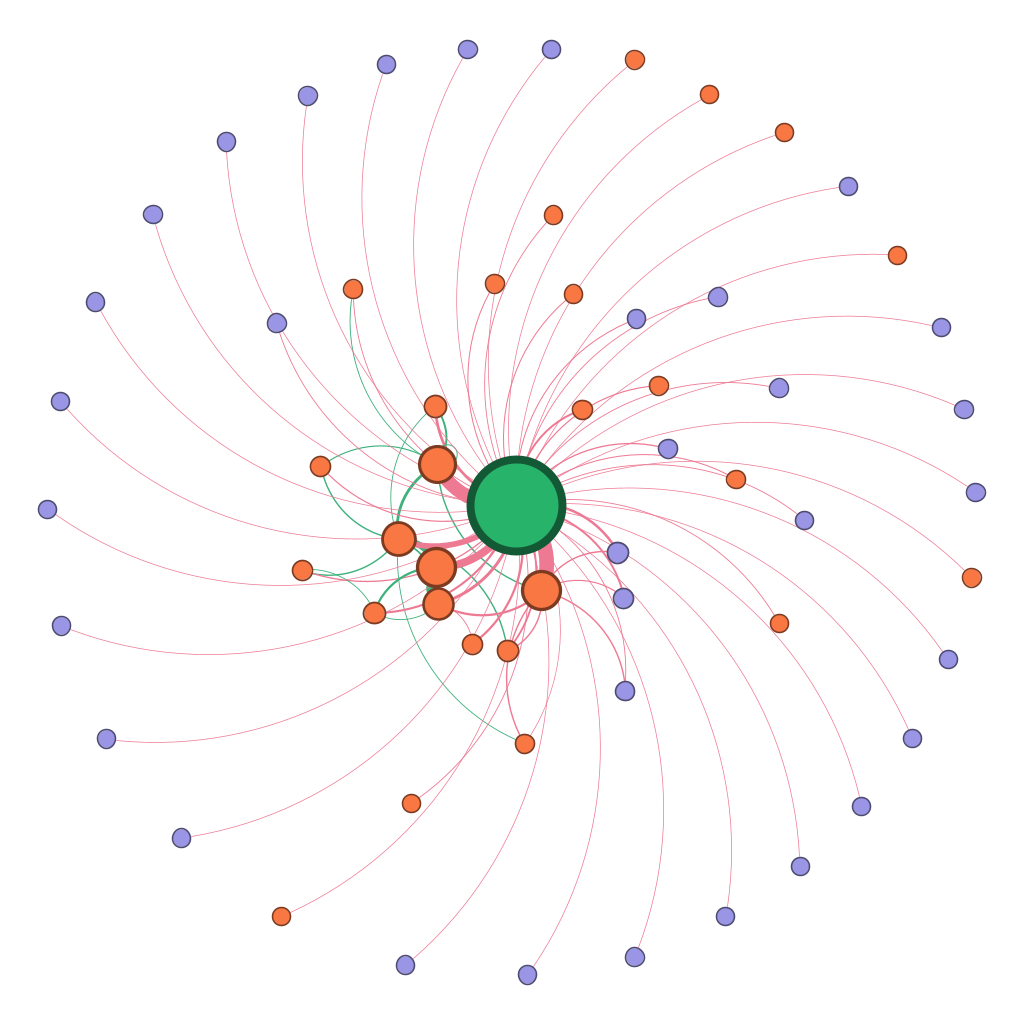

In [75]:
# PNG NETWORK PAGERANK (with and without labels)
display(Image('png_gephi/graph2_pagerank_labels.png'))
display(Image('png_gephi/graph2_pagerank_no_labels.png'))

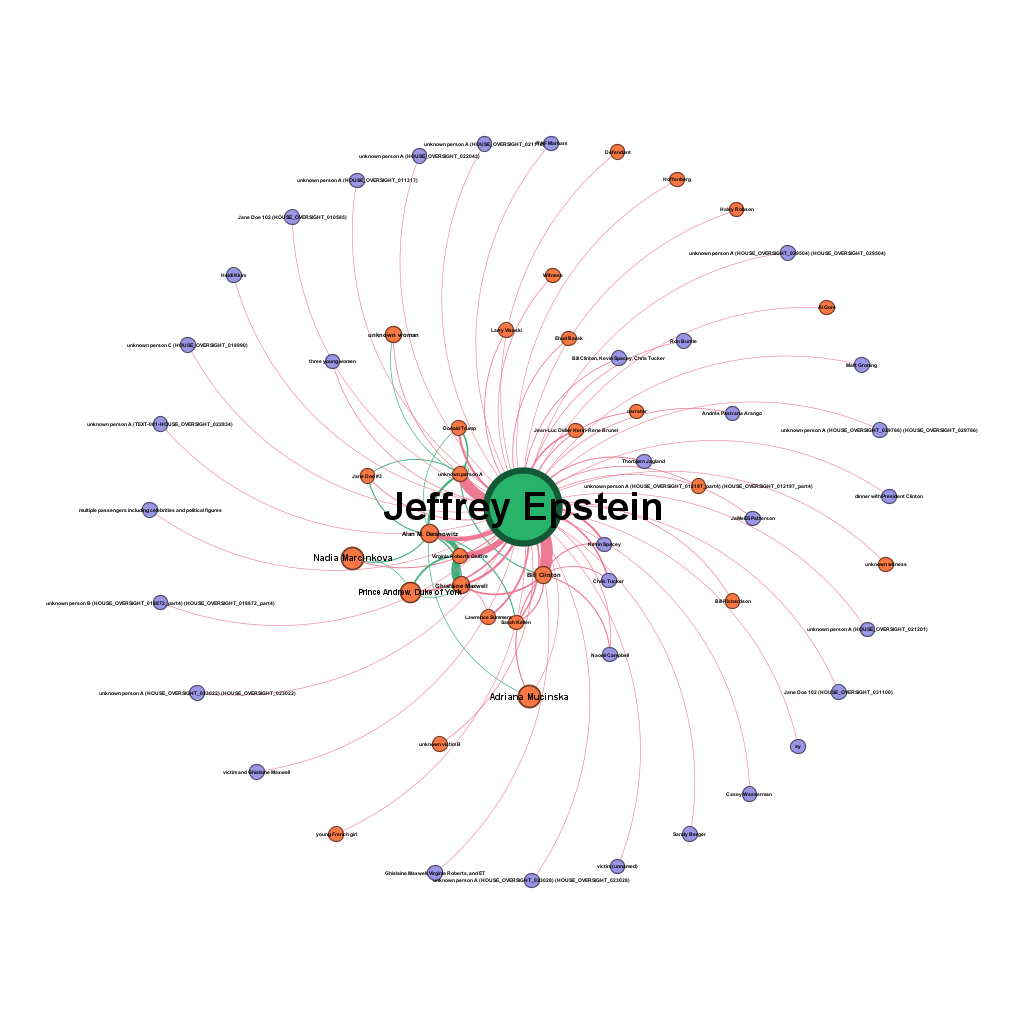

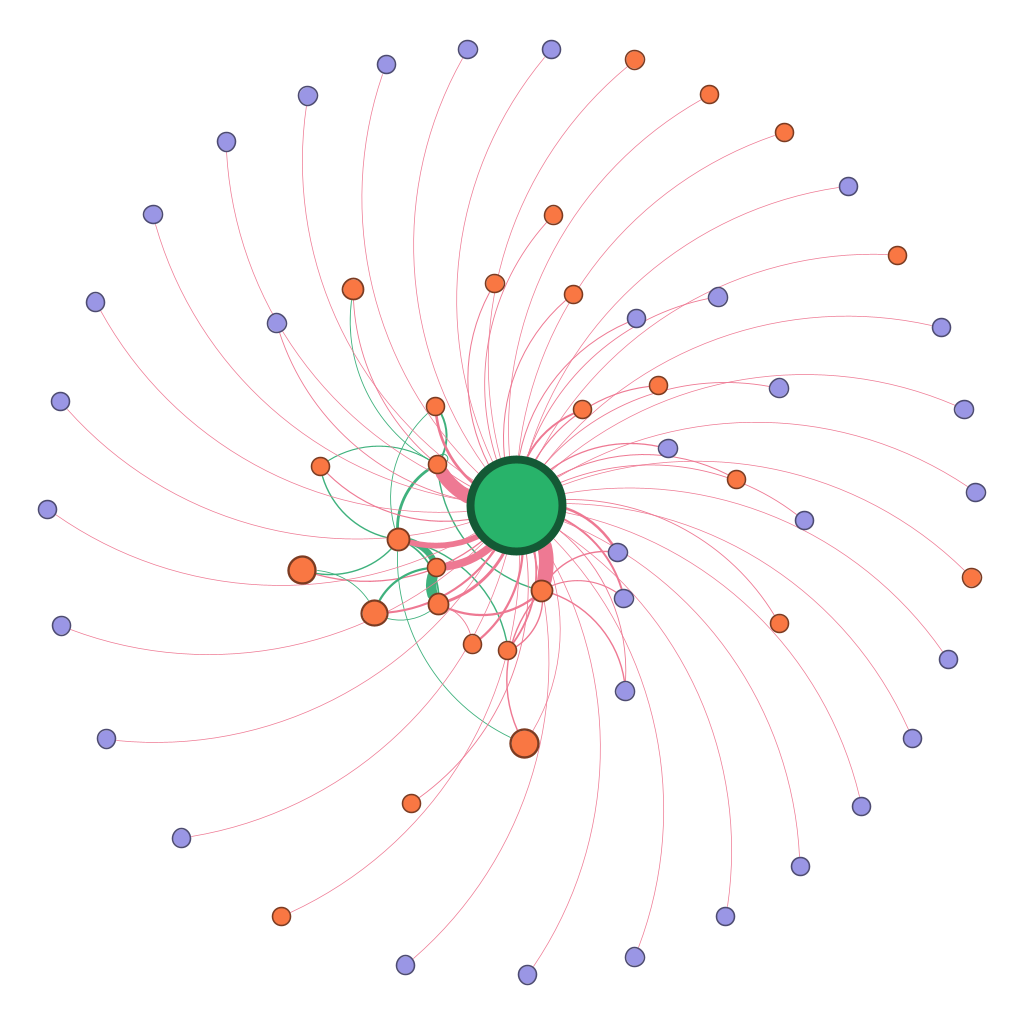

In [76]:
# PNG NETWORK BETWEENNESS (with and without labels)
display(Image('png_gephi/graph2_betweenness_labels.png'))
display(Image('png_gephi/graph2_betweenness_no_labels.png'))

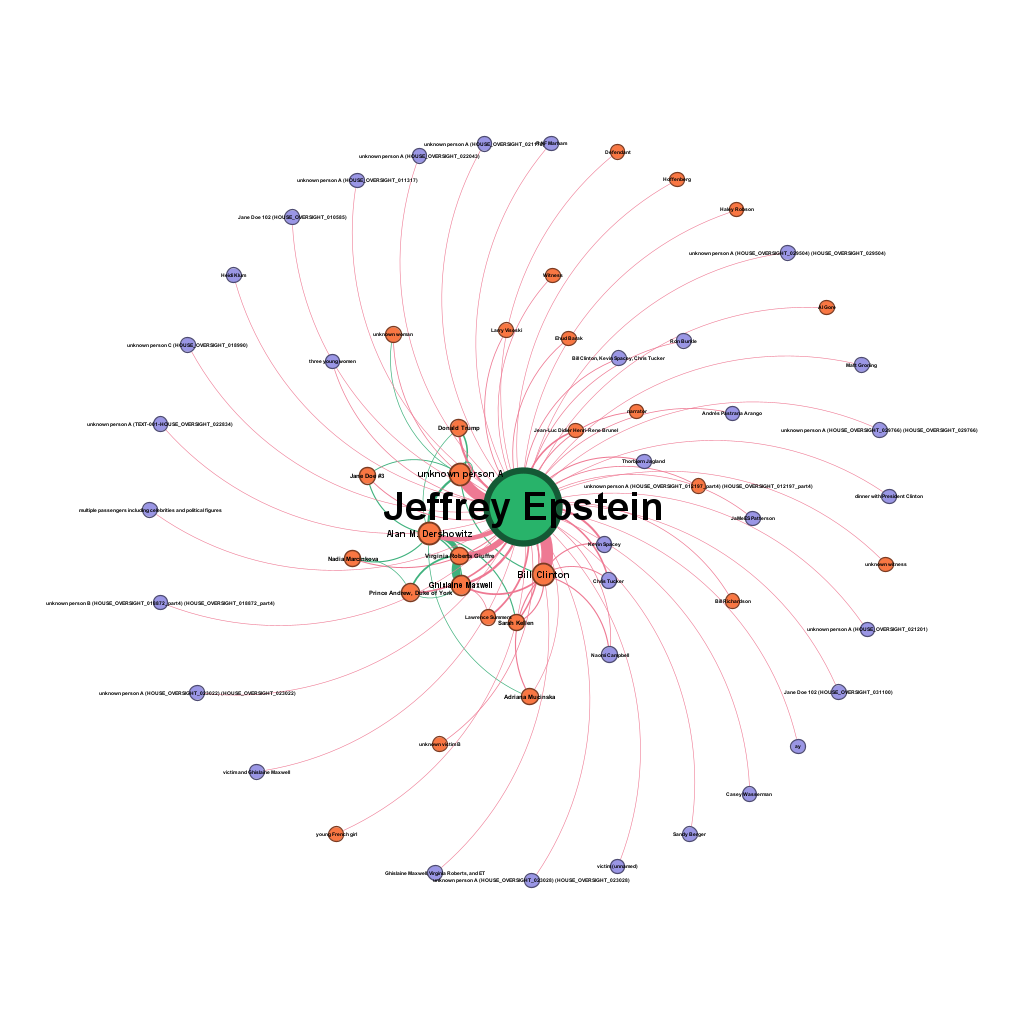

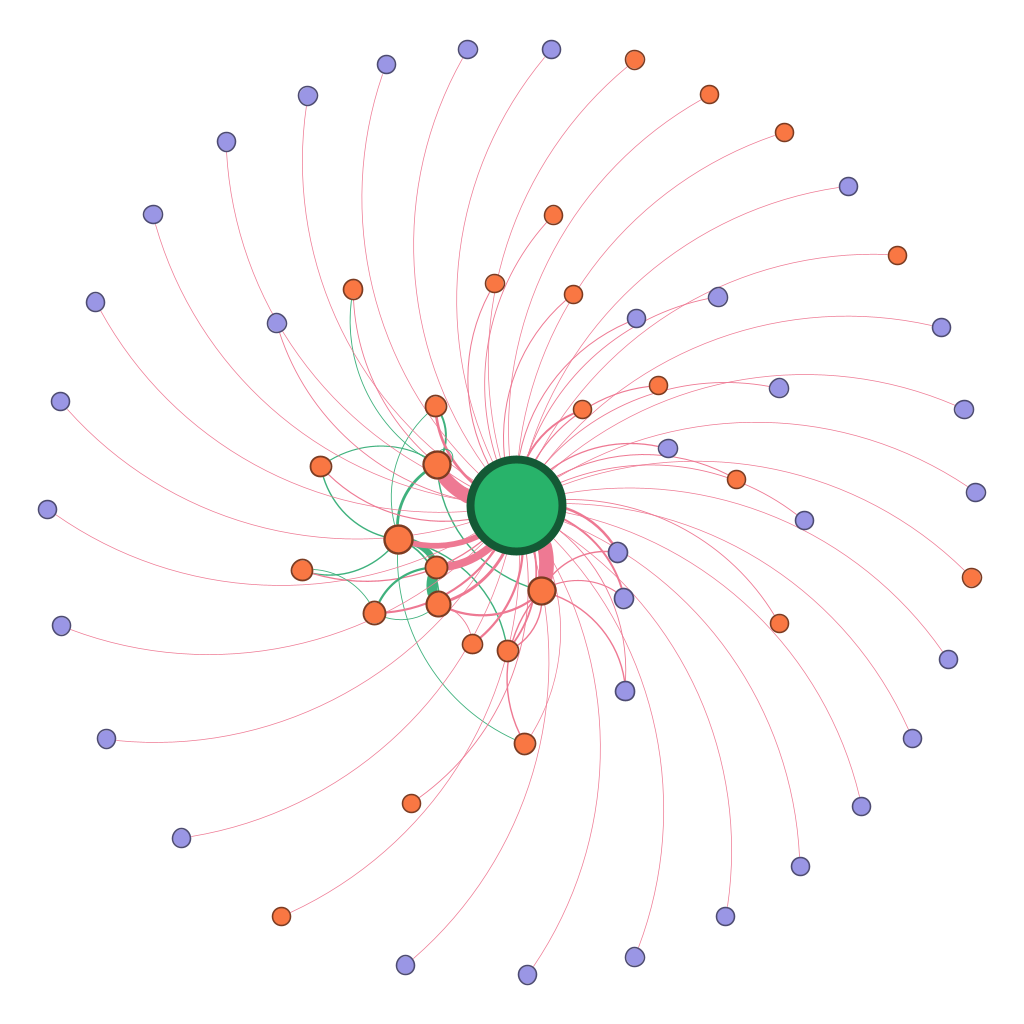

In [77]:
# PNG NETWORK DEGREE (with and without labels)
display(Image('png_gephi/graph2_degreecentrality_labels.png'))
display(Image('png_gephi/graph2_degreecentrality_no_labels.png'))

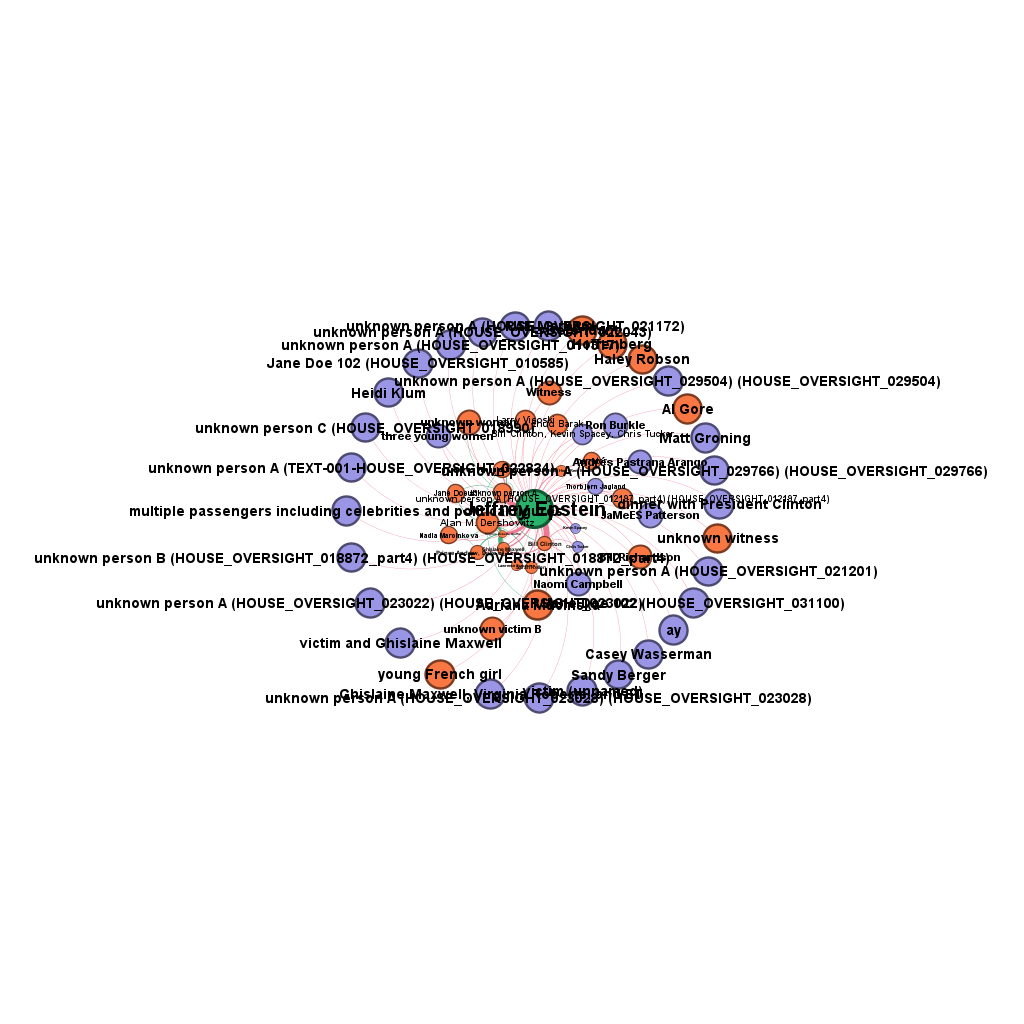

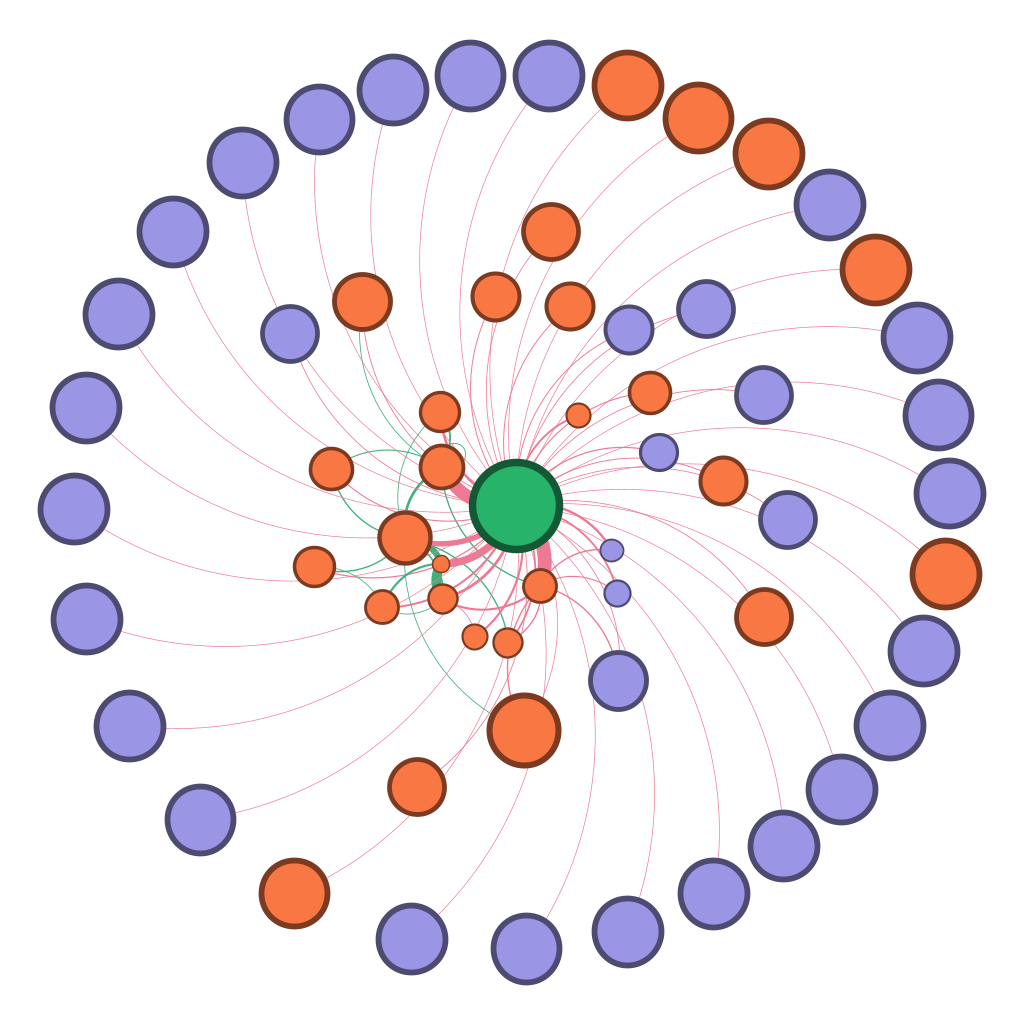

In [78]:
# PNG NETWORK closeness (with and without labels) -
# less interesting (as is a kind of star graph with epstein really in the middle 
# closeness of all quite similar
display(Image('png_gephi/graph2_closeness_labels.png'))
display(Image('png_gephi/graph2_closeness_no_labels.png'))

#### Heat map on centrality metrics (order and top 20 based on betweenness of full graph) 
NOTE: epstein himself not included, as he would dominate all metrics

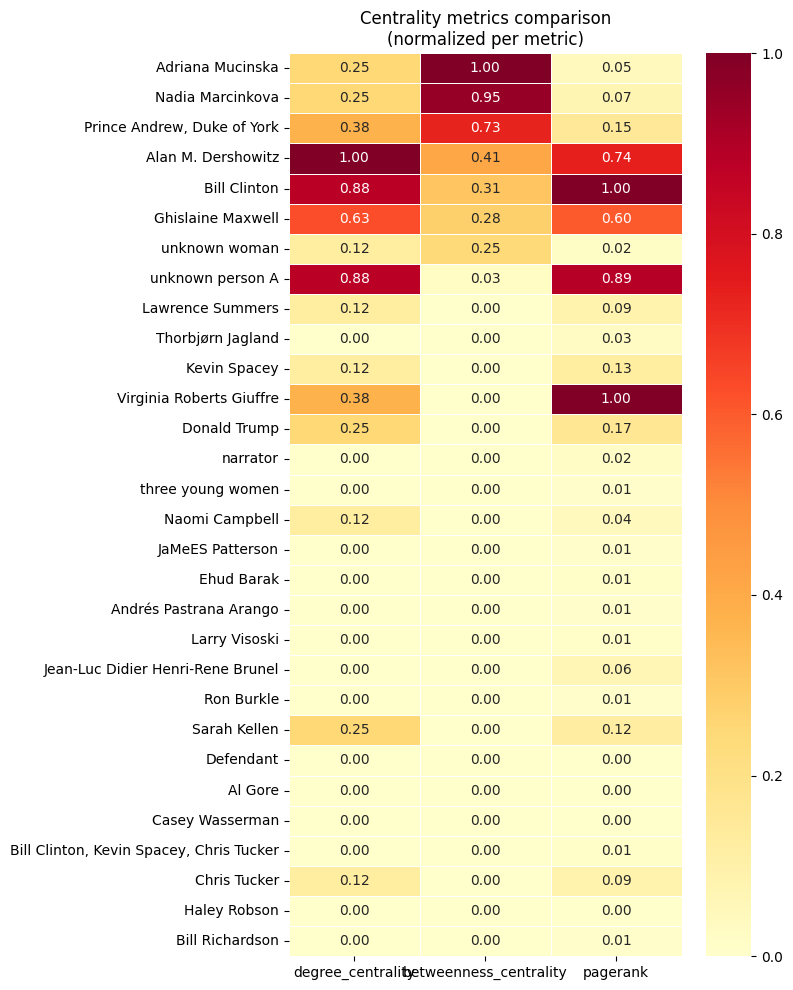

In [ ]:
# Heatmap on the centrality metrics (on top 20 of betweenness) 
# NOTE: (epstein himself not included, as he would dominate all metrics)
df_heat = df_centrality[df_centrality['entity'] != 'Jeffrey Epstein'].copy()
df_heat = df_heat.head(30)  

# Normalizing metrics 
metrics = ['degree_centrality', 'betweenness_centrality', 'pagerank']
df_heat_norm = df_heat[metrics].copy()
for col in metrics:
    df_heat_norm[col] = (df_heat_norm[col] - df_heat_norm[col].min()) / (df_heat_norm[col].max() - df_heat_norm[col].min())

df_heat_norm.index = df_heat['entity'].values

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(df_heat_norm, 
            annot=True, fmt='.2f',
            cmap='YlOrRd',
            linewidths=0.5,
            ax=ax)
ax.set_title('Centrality metrics comparison\n(normalized per metric)', fontsize=12)
plt.tight_layout()
plt.show()

#### Bar plots bridge nodes vs aviation only nodes
NOTE: epstein himself not included as he would dominate all metrics

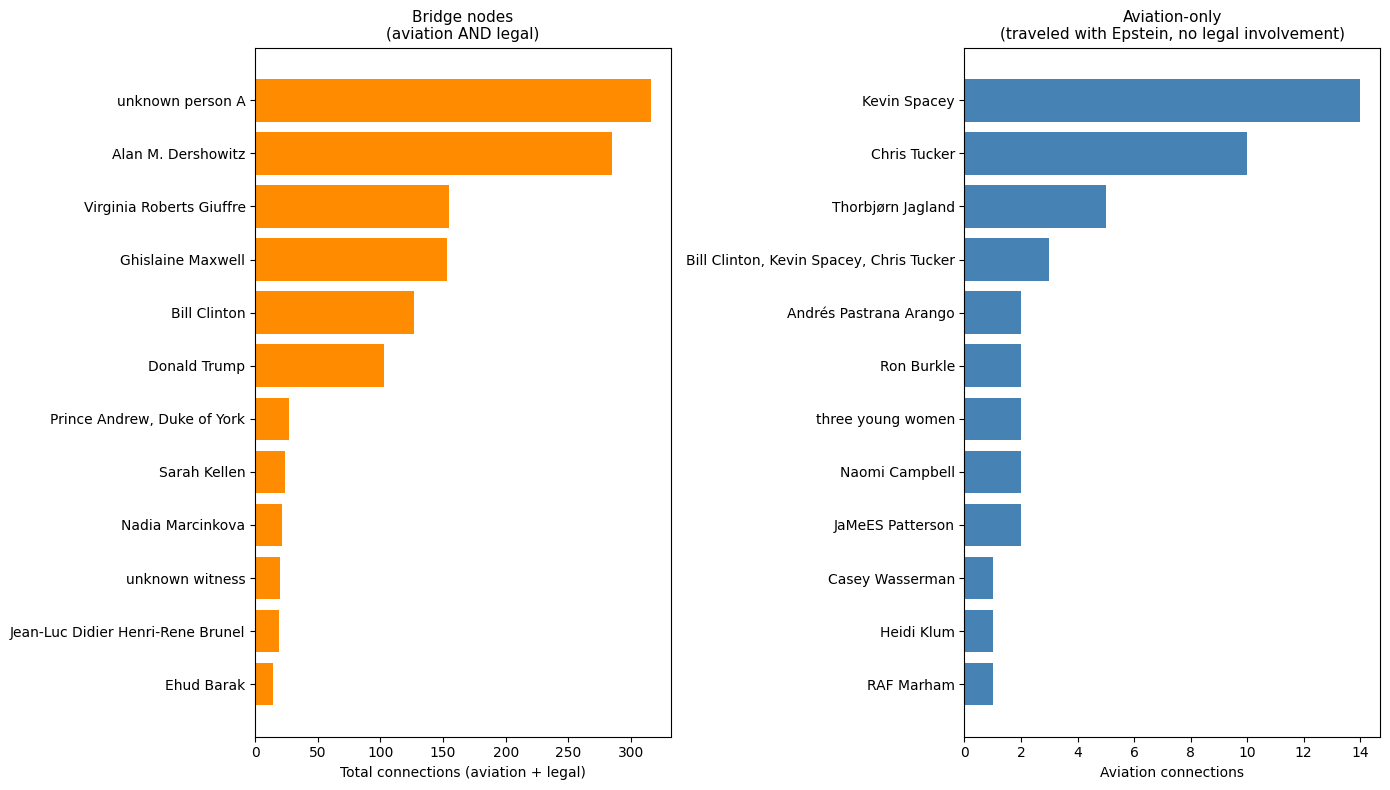

In [ ]:
## BAR PLOTS BRIDGE NODES VS AVIATION ONLY 
## NOTE: epstein himself not included as he would dominate all metrics

#  Aviation only — entities without legal connections
aviation_only = bridge_nodes[bridge_nodes['legal_count'] == 0].copy()

# Bridge nodes — entities both in legal and aviation network
bridge_only = bridge_nodes[bridge_nodes['legal_count'] > 0].copy()
# Verwijder Epstein zelf
bridge_only = bridge_only[bridge_only['entity'] != 'Jeffrey Epstein']

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Bridge nodes
top_bridge = bridge_only.head(12)
axes[0].barh(top_bridge['entity'][::-1], top_bridge['total'][::-1], color='darkorange')
axes[0].set_xlabel('Total connections (aviation + legal)')
axes[0].set_title('Bridge nodes\n(aviation AND legal)', fontsize=11)

# Aviation only
top_avi_only = aviation_only.head(12)
axes[1].barh(top_avi_only['entity'][::-1], top_avi_only['connection_count'][::-1], color='steelblue')
axes[1].set_xlabel('Aviation connections')
axes[1].set_title('Aviation-only\n(traveled with Epstein, no legal involvement)', fontsize=11)

plt.tight_layout()
plt.show()

#### TABLES SOCIOMETRICS + BARCHARTS per combined netw / aviation netw / legal netw on aviation netw
 NOTE: epstein himself not included as he would dominate all metric

In [ ]:
# ============================================================
# SOCIOMETRICS - ALL NETWORKS -
# ============================================================


# --- G_combined already built earlier ---

# --- G_aviation: aviation edges only ---
G_aviation = nx.Graph()

for _, row in epstein_aviation_edges.iterrows():
    G_aviation.add_edge(row['source'], row['target'],
                        weight=row['weight'],
                        edge_type='aviation')

for (src, tgt), group in df_edges_aviation.groupby(['source', 'target']):
    weight = len(group)
    if G_aviation.has_edge(src, tgt):
        G_aviation[src][tgt]['weight'] += weight
    else:
        G_aviation.add_edge(src, tgt, weight=weight, edge_type='aviation')

# --- G_legal: legal edges only ---
G_legal = nx.Graph()

df_legal_only = pd.concat([df_edges_legal, df_epstein_legal_edges], ignore_index=True)
for (src, tgt), group in df_legal_only.groupby(['source', 'target']):
    weight = len(group)
    if G_legal.has_edge(src, tgt):
        G_legal[src][tgt]['weight'] += weight
    else:
        G_legal.add_edge(src, tgt, weight=weight, edge_type='legal')

print(f"G_combined: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"G_aviation: {G_aviation.number_of_nodes()} nodes, {G_aviation.number_of_edges()} edges")
print(f"G_legal: {G_legal.number_of_nodes()} nodes, {G_legal.number_of_edges()} edges")

# --- Centrality metrics combined ---
df_centrality_combined = pd.DataFrame({
    'entity': list(nx.degree_centrality(G).keys()),
    'degree_combined': list(nx.degree_centrality(G).values()),
    'betweenness': list(nx.betweenness_centrality(G, weight='weight').values()),
    'pagerank_combined': list(nx.pagerank(G, weight='weight').values()),
    'closeness': list(nx.closeness_centrality(G, distance='weight').values()),
})

# --- Centrality metrics aviation ---
df_centrality_aviation = pd.DataFrame({
    'entity': list(nx.degree_centrality(G_aviation).keys()),
    'degree_aviation': list(nx.degree_centrality(G_aviation).values()),
    'betweenness_aviation': list(nx.betweenness_centrality(G_aviation, weight='weight').values()),
    'pagerank_aviation': list(nx.pagerank(G_aviation, weight='weight').values()),
    'closeness_aviation': list(nx.closeness_centrality(G_aviation, distance='weight').values()),
})

# --- Centrality metrics legal ---
df_centrality_legal = pd.DataFrame({
    'entity': list(nx.degree_centrality(G_legal).keys()),
    'degree_legal': list(nx.degree_centrality(G_legal).values()),
    'betweenness_legal': list(nx.betweenness_centrality(G_legal, weight='weight').values()),
    'pagerank_legal': list(nx.pagerank(G_legal, weight='weight').values()),
    'closeness_legal': list(nx.closeness_centrality(G_legal, distance='weight').values()),
})

# --- Merge all metrics ---
df_all_metrics = bridge_nodes[['entity', 'connection_count', 'legal_count', 'total']].copy()
df_all_metrics = df_all_metrics.rename(columns={
    'connection_count': 'aviation_count',
    'total': 'total_count'
})

df_all_metrics = df_all_metrics\
    .merge(df_centrality_combined, on='entity', how='left')\
    .merge(df_centrality_aviation, on='entity', how='left')\
    .merge(df_centrality_legal, on='entity', how='left')\
    .fillna(0)

# --- Fix Epstein counts ---
df_all_metrics.loc[df_all_metrics['entity'] == 'Jeffrey Epstein', 'aviation_count'] = len(aviation_consolidated)
df_all_metrics.loc[df_all_metrics['entity'] == 'Jeffrey Epstein', 'legal_count'] = len(df_epstein_legal_edges)
df_all_metrics.loc[df_all_metrics['entity'] == 'Jeffrey Epstein', 'total_count'] = len(aviation_consolidated) + len(df_epstein_legal_edges)

# --- Network category ---
df_all_metrics['network'] = df_all_metrics.apply(
    lambda row: 'epstein' if row['entity'] == 'Jeffrey Epstein'
    else 'aviation + legal' if row['legal_count'] > 0
    else 'aviation only',
    axis=1
)

# --- Sort on total_count ---
df_all_metrics = df_all_metrics.sort_values('total_count', ascending=False).reset_index(drop=True)

print(f"Total rows: {len(df_all_metrics)}")
print(df_all_metrics[['entity', 'aviation_count', 'legal_count', 'total_count', 'network']].head(10).to_string())

# ============================================================
# TABLES
# ============================================================

def make_table(df, cols, caption, gradient_cols):
    styled = df[cols].round(4).style
    for col, cmap in gradient_cols.items():
        if col in cols:
            styled = styled.background_gradient(subset=[col], cmap=cmap)
    if 'network' in cols:
        styled = styled.applymap(
            lambda v: 'background-color: #ffe066' if v == 'aviation + legal'
            else 'background-color: #a8d8ea' if v == 'aviation only'
            else 'background-color: #90ee90',
            subset=['network']
        )
    styled = styled.set_caption(caption)\
        .format({c: '{:.4f}' for c in cols if c not in ['entity', 'network', 'aviation_count', 'legal_count', 'total_count']})
    display(styled)

gradient_cols = {
    'aviation_count': 'Blues',
    'legal_count': 'Oranges',
    'total_count': 'Greys',
    'betweenness': 'Reds',
    'pagerank_combined': 'Greens',
    'closeness': 'Purples',
    'degree_aviation': 'Blues',
    'betweenness_aviation': 'Reds',
    'pagerank_aviation': 'Greens',
    'closeness_aviation': 'Purples',
    'degree_legal': 'Oranges',
    'betweenness_legal': 'Reds',
    'pagerank_legal': 'Greens',
    'closeness_legal': 'Purples',
}

# TABLE 1
cols_combined = ['entity', 'network', 'aviation_count', 'legal_count', 'total_count',
                 'betweenness', 'pagerank_combined', 'closeness']
print("=== TABLE 1: COMBINED NETWORK ===")
make_table(df_all_metrics, cols_combined, 'Table 1: Combined network', gradient_cols)

# TABLE 2
cols_aviation = ['entity', 'aviation_count',
                 'degree_aviation', 'betweenness_aviation', 'pagerank_aviation', 'closeness_aviation']
print("=== TABLE 2: AVIATION NETWORK ALONE ===")
make_table(df_all_metrics, cols_aviation, 'Table 2: Aviation network alone', gradient_cols)

# TABLE 3
cols_legal = ['entity', 'legal_count',
              'degree_legal', 'betweenness_legal', 'pagerank_legal', 'closeness_legal']
print("=== TABLE 3: LEGAL NETWORK ALONE ===")
make_table(df_all_metrics[df_all_metrics['legal_count'] > 0],
           cols_legal, 'Table 3: Legal network alone (bridge nodes only)', gradient_cols)

G_combined: 61 nodes, 84 edges
G_aviation: 61 nodes, 70 edges
G_legal: 22 nodes, 37 edges
Total rows: 60
                        entity  aviation_count  legal_count  total_count           network
0             unknown person A               6          310          316  aviation + legal
1           Alan M. Dershowitz              14          271          285  aviation + legal
2     Virginia Roberts Giuffre              19          136          155  aviation + legal
3            Ghislaine Maxwell              14          139          153  aviation + legal
4                 Bill Clinton             100           27          127  aviation + legal
5                 Donald Trump               3          100          103  aviation + legal
6  Prince Andrew, Duke of York               8           19           27  aviation + legal
7                 Sarah Kellen               2           22           24  aviation + legal
8             Nadia Marcinkova               1           20           21  av

C:\Users\fienm\AppData\Local\Temp\ipykernel_1000\4162383353.py:106: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = styled.applymap(


,entity,network,aviation_count,legal_count,total_count,betweenness,pagerank_combined,closeness
0,unknown person A,aviation + legal,6,310,316,0.0031,0.0814,0.1504
1,Alan M. Dershowitz,aviation + legal,14,271,285,0.0511,0.0683,0.1824
2,Virginia Roberts Giuffre,aviation + legal,19,136,155,0.0000,0.0914,0.0480
3,Ghislaine Maxwell,aviation + legal,14,139,153,0.0345,0.0565,0.0940
4,Bill Clinton,aviation + legal,100,27,127,0.0390,0.0914,0.1115
5,Donald Trump,aviation + legal,3,100,103,0.0000,0.0178,0.1342
6,"Prince Andrew, Duke of York",aviation + legal,8,19,27,0.0904,0.0165,0.1109
7,Sarah Kellen,aviation + legal,2,22,24,0.0000,0.0139,0.0912
8,Nadia Marcinkova,aviation + legal,1,20,21,0.1181,0.0094,0.1379
9,unknown witness,aviation + legal,1,19,20,0.0000,0.0031,0.2449


=== TABLE 2: AVIATION NETWORK ALONE ===


,entity,aviation_count,degree_aviation,betweenness_aviation,pagerank_aviation,closeness_aviation
0,unknown person A,6,0.0333,0.0000,0.0144,0.1222
1,Alan M. Dershowitz,14,0.0500,0.0333,0.0270,0.0659
2,Virginia Roberts Giuffre,19,0.0333,0.0000,0.0291,0.0584
3,Ghislaine Maxwell,14,0.0667,0.0068,0.0404,0.0816
4,Bill Clinton,100,0.1333,0.0390,0.1819,0.1165
5,Donald Trump,3,0.0167,0.0000,0.0063,0.1760
6,"Prince Andrew, Duke of York",8,0.0167,0.0000,0.0127,0.0943
7,Sarah Kellen,2,0.0333,0.0000,0.0115,0.2190
8,Nadia Marcinkova,1,0.0167,0.0000,0.0037,0.2691
9,unknown witness,1,0.0167,0.0000,0.0037,0.2691


=== TABLE 3: LEGAL NETWORK ALONE ===


,entity,legal_count,degree_legal,betweenness_legal,pagerank_legal,closeness_legal
0,unknown person A,310,0.3810,0.0000,0.1508,0.1544
1,Alan M. Dershowitz,271,0.4286,0.1833,0.1204,0.1265
2,Virginia Roberts Giuffre,136,0.1905,0.0000,0.1555,0.0587
3,Ghislaine Maxwell,139,0.1905,0.2048,0.0766,0.1810
4,Bill Clinton,27,0.0952,0.0000,0.0112,0.1721
5,Donald Trump,100,0.1429,0.0000,0.0328,0.1029
6,"Prince Andrew, Duke of York",19,0.1905,0.1000,0.0246,0.1780
7,Sarah Kellen,22,0.0952,0.0000,0.0206,0.1045
8,Nadia Marcinkova,20,0.1429,0.0000,0.0194,0.1533
9,unknown witness,19,0.0000,0.0000,0.0000,0.0000


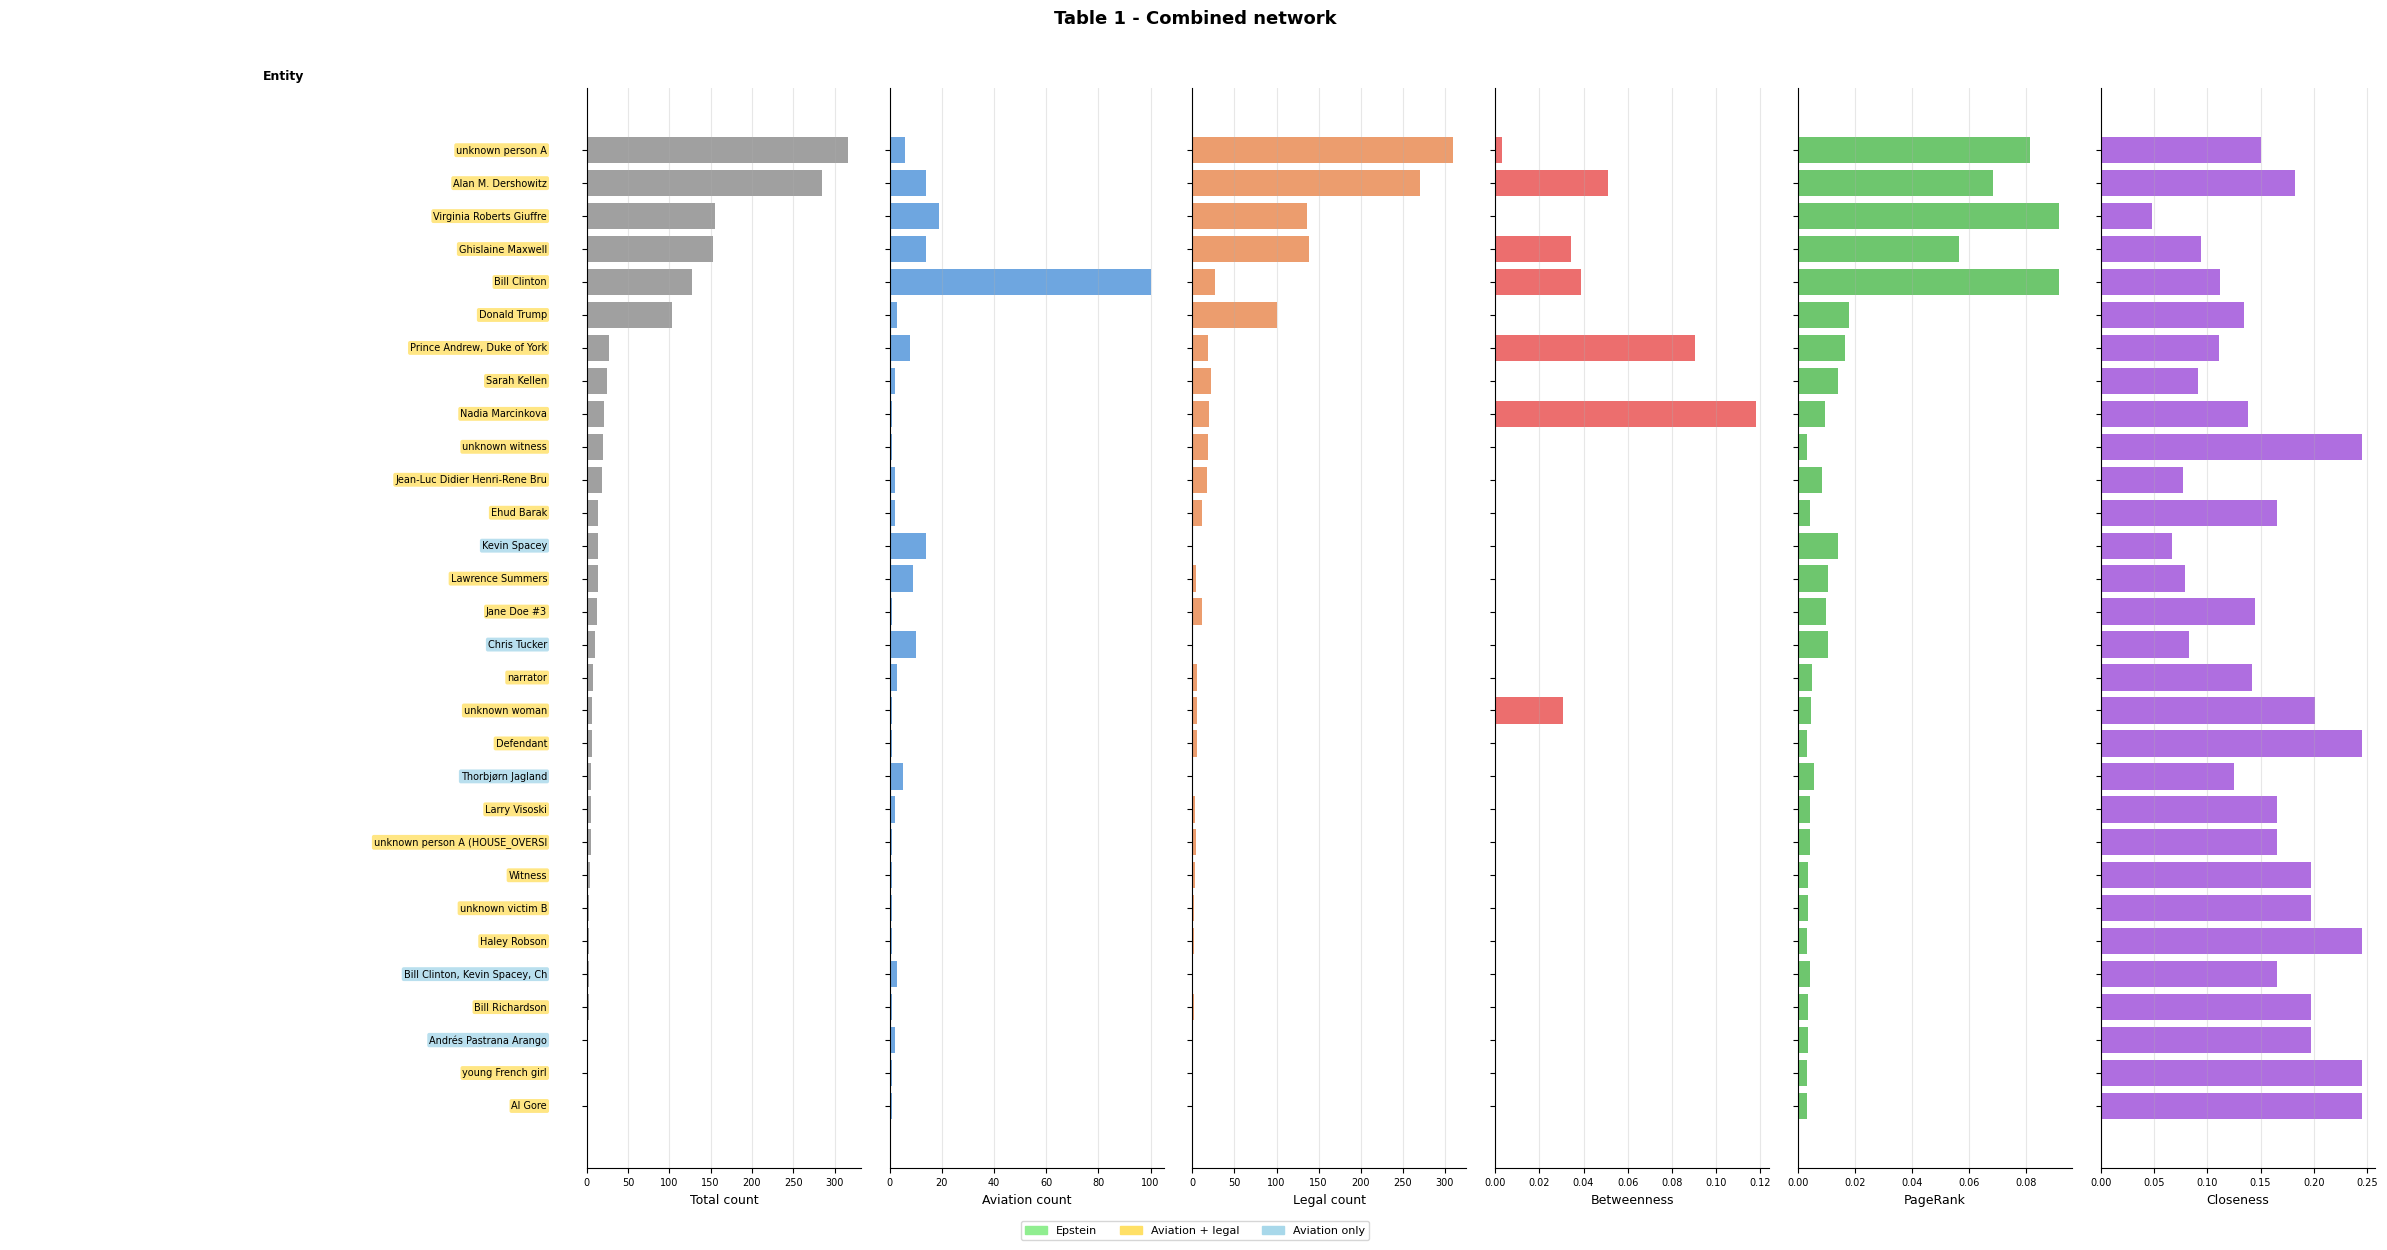

Saved: table_1_-_combined_network.png


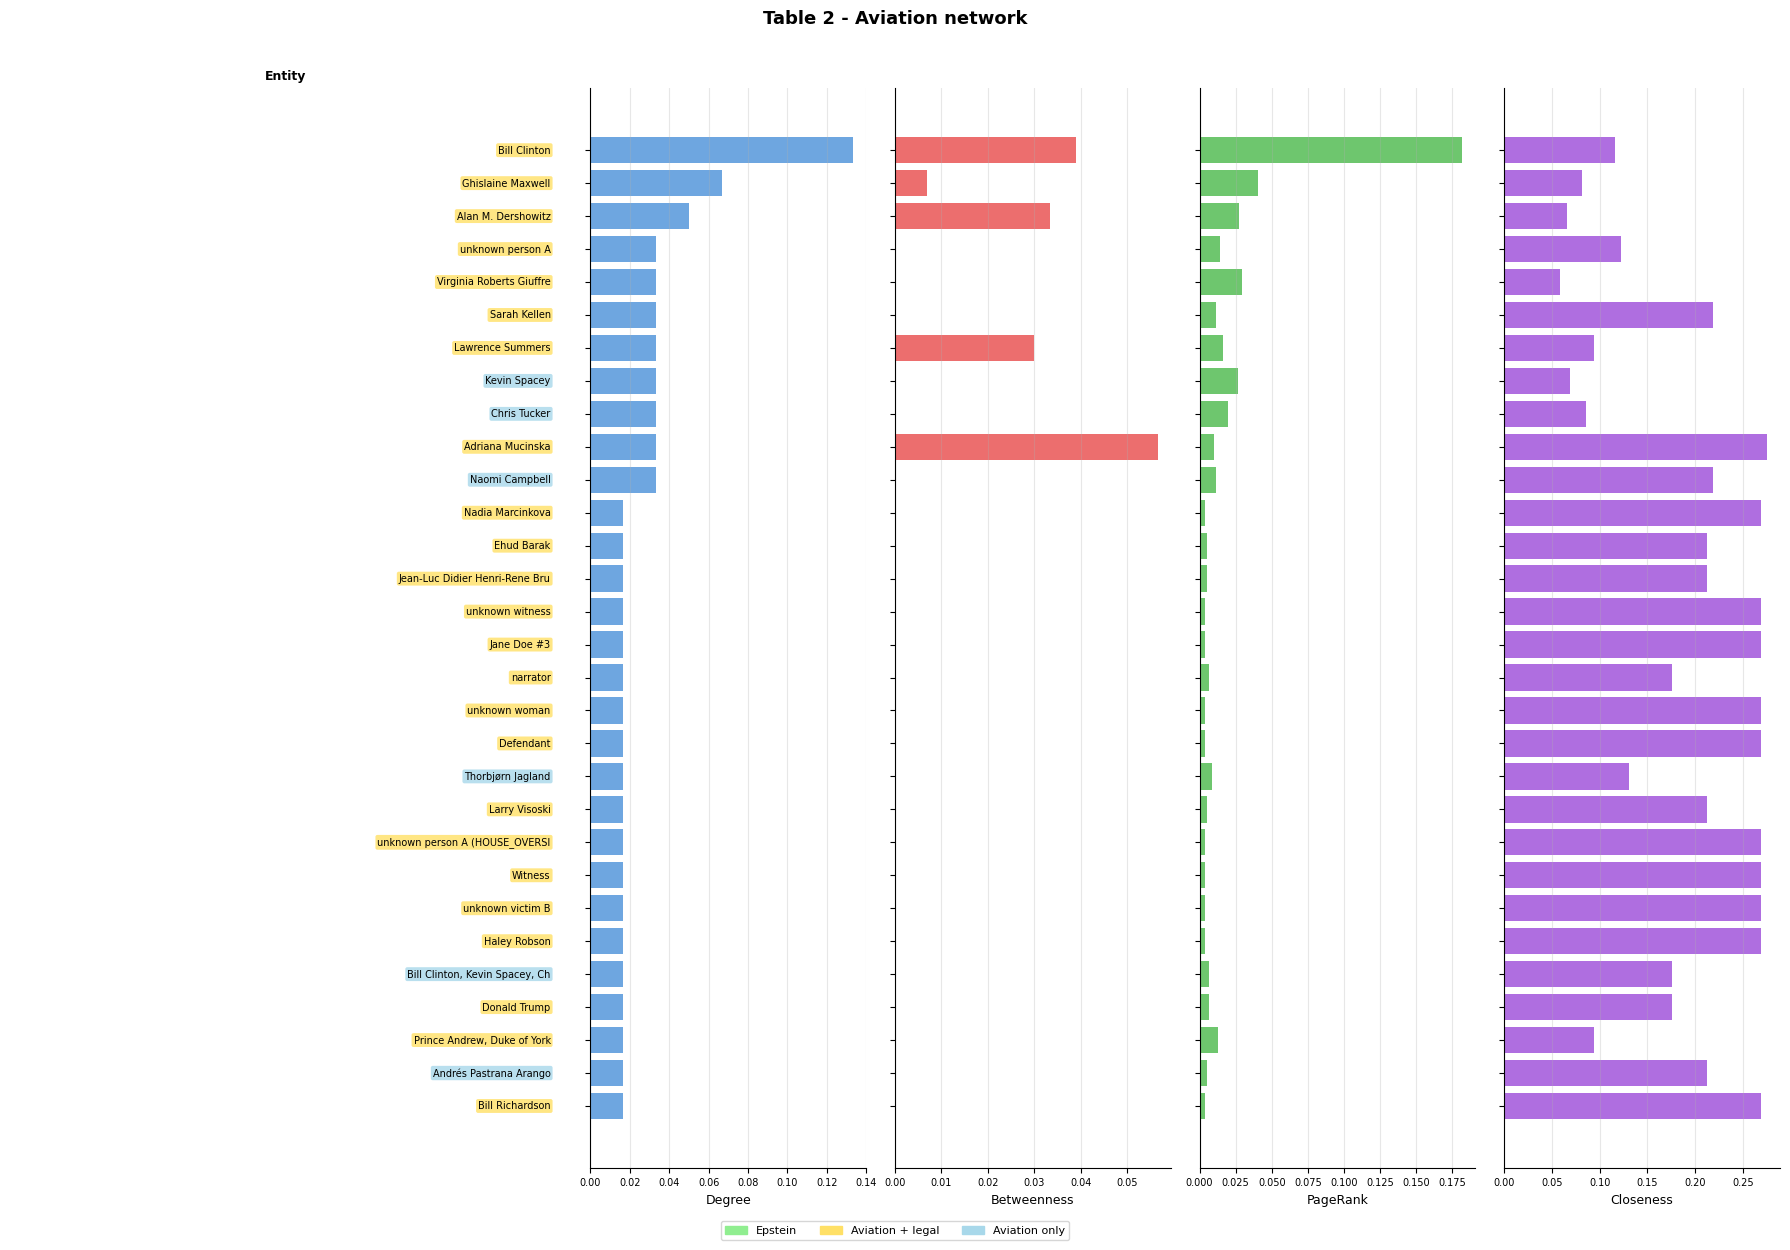

Saved: table_2_-_aviation_network.png


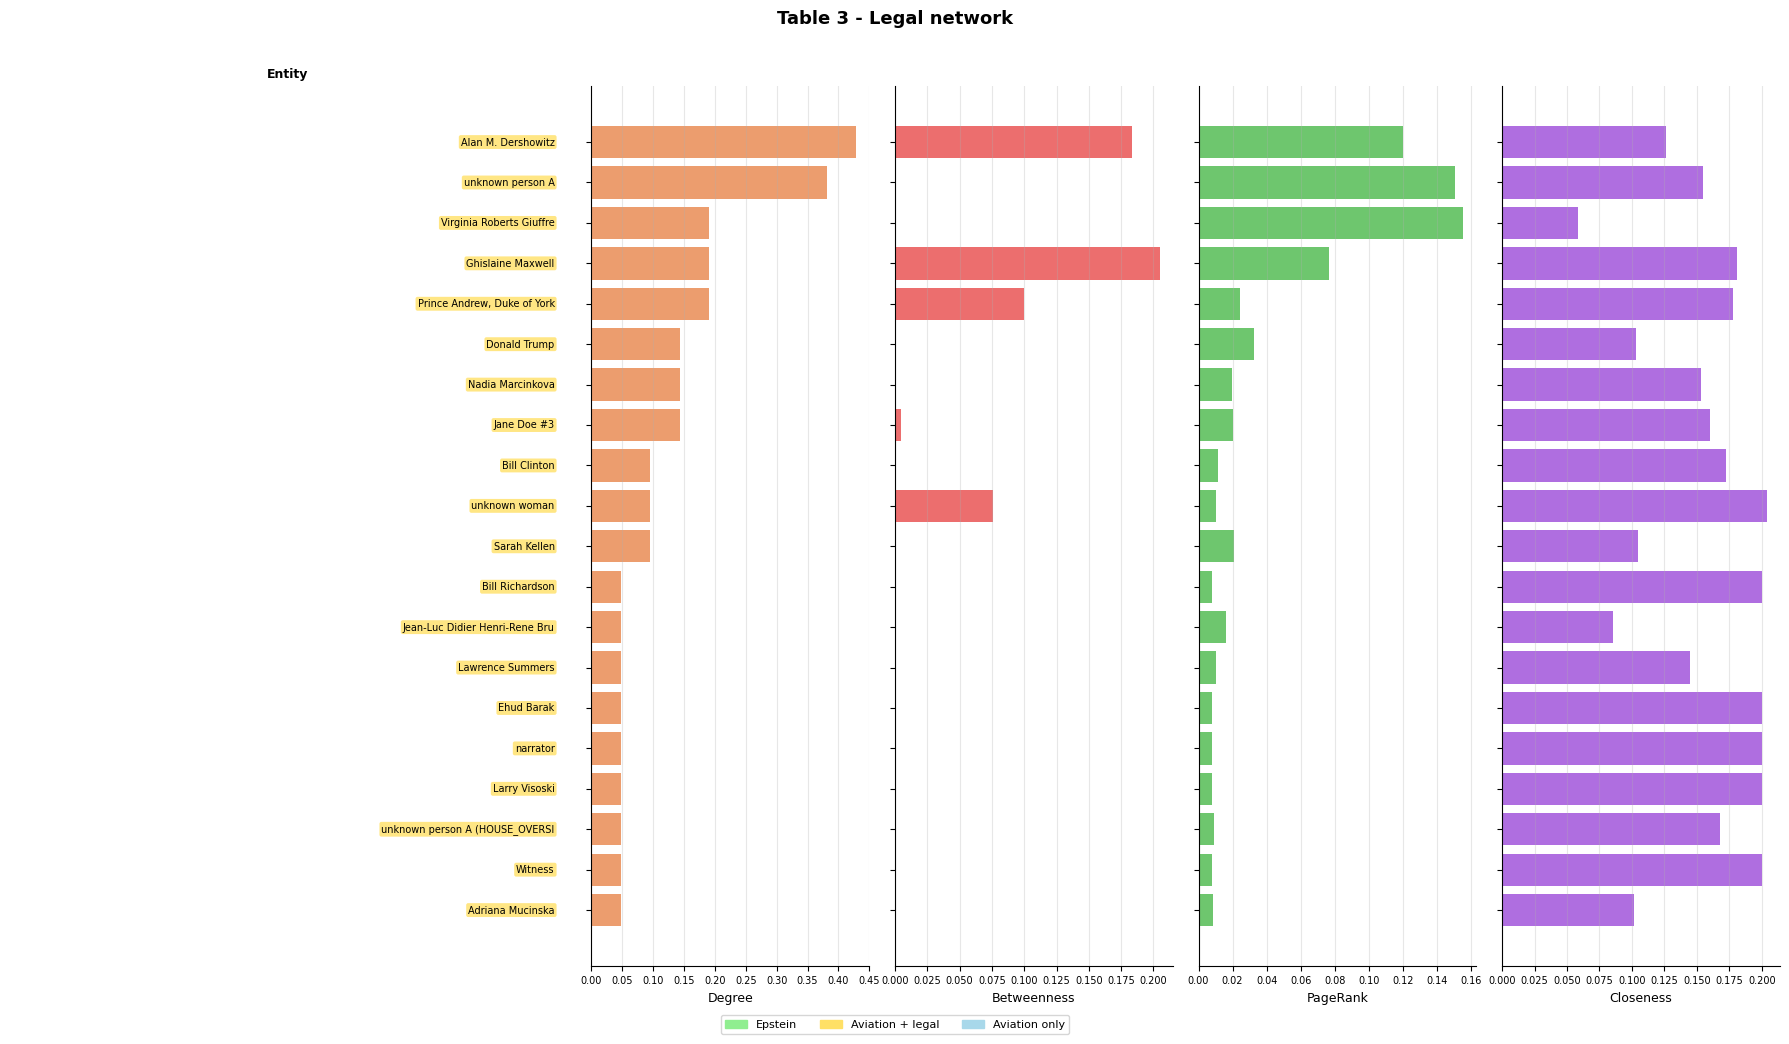

Saved: table_3_-_legal_network.png


In [90]:
def make_small_multiples(df, metrics, title, sort_by, top_n=30, figsize=(24, 12)):
    df_top = df.sort_values(sort_by, ascending=False).head(top_n).copy().reset_index(drop=True)
    entities = df_top['entity'].str[:30]  # truncate long names
    
    n_metrics = len(metrics)
    # +1 for names column on the left
    fig, axes = plt.subplots(1, n_metrics + 1, figsize=figsize,
                              gridspec_kw={'width_ratios': [2] + [1] * n_metrics})
    
    # Network colors
    network_colors = {
        'epstein': '#90ee90',
        'aviation + legal': '#ffe066',
        'aviation only': '#a8d8ea',
    }
    
    colors = {
        'aviation_count': '#4a90d9',
        'legal_count': '#e8854a',
        'total_count': '#888888',
        'betweenness': '#e84a4a',
        'betweenness_aviation': '#e84a4a',
        'betweenness_legal': '#e84a4a',
        'pagerank_combined': '#4ab84a',
        'pagerank_aviation': '#4ab84a',
        'pagerank_legal': '#4ab84a',
        'closeness': '#9b4ad9',
        'closeness_aviation': '#9b4ad9',
        'closeness_legal': '#9b4ad9',
        'degree_aviation': '#4a90d9',
        'degree_legal': '#e8854a',
        'degree_combined': '#888888',
    }
    
    labels = {
        'aviation_count': 'Aviation count',
        'legal_count': 'Legal count',
        'total_count': 'Total count',
        'betweenness': 'Betweenness',
        'betweenness_aviation': 'Betweenness',
        'betweenness_legal': 'Betweenness',
        'pagerank_combined': 'PageRank',
        'pagerank_aviation': 'PageRank',
        'pagerank_legal': 'PageRank',
        'closeness': 'Closeness',
        'closeness_aviation': 'Closeness',
        'closeness_legal': 'Closeness',
        'degree_aviation': 'Degree',
        'degree_legal': 'Degree',
        'degree_combined': 'Degree',
    }

    # LEFT PANEL: entity names
    ax_names = axes[0]
    ax_names.set_xlim(0, 1)
    ax_names.set_ylim(-0.5, top_n - 0.5)
    ax_names.invert_yaxis()
    ax_names.axis('off')

    for i, (name, net) in enumerate(zip(entities, df_top['network'].values)):
        bg_color = network_colors.get(net, 'white')
        ax_names.text(
            0.98, i,  # i = exact bar position
            name,
            ha='right', va='center', fontsize=7,
            bbox=dict(boxstyle='round,pad=0.2', facecolor=bg_color, alpha=0.8, edgecolor='none')
        )
    ax_names.set_title('Entity', fontsize=9, fontweight='bold')

    # METRIC PANELS
    for i, metric in enumerate(metrics):
        ax = axes[i + 1]
        values = df_top[metric].values
        color = colors.get(metric, '#888888')
        
        ax.barh(range(top_n), values, color=color, alpha=0.8)
        ax.set_yticks(range(top_n))
        ax.set_yticklabels([])
        ax.set_xlabel(labels.get(metric, metric), fontsize=9)
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='x', labelsize=7)
    
    # Aligning entity names with plots
    ylim = axes[1].get_ylim()
    ax_names.set_ylim(ylim)

    # Legend
    legend_patches = [
        mpatches.Patch(color='#90ee90', label='Epstein'),
        mpatches.Patch(color='#ffe066', label='Aviation + legal'),
        mpatches.Patch(color='#a8d8ea', label='Aviation only'),
    ]
    fig.legend(handles=legend_patches, loc='lower center', ncol=3,
               fontsize=8, bbox_to_anchor=(0.5, -0.02))

    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    filename = f'{title.replace(" ", "_").replace("/", "").lower()}.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


# TABLE 1 small multiples
make_small_multiples(
    df_all_metrics,
    metrics=['total_count', 'aviation_count', 'legal_count', 'betweenness', 'pagerank_combined', 'closeness'],
    title='Table 1 - Combined network',
    sort_by='total_count',
    top_n=30,
    figsize=(24, 12)
)

# TABLE 2 small multiples
make_small_multiples(
    df_all_metrics,
    metrics=['degree_aviation', 'betweenness_aviation', 'pagerank_aviation', 'closeness_aviation'],
    title='Table 2 - Aviation network',
    sort_by='degree_aviation',
    top_n=30,
    figsize=(18, 12)
)

# TABLE 3 small multiples - bridge nodes only
make_small_multiples(
    df_all_metrics[df_all_metrics['legal_count'] > 0].reset_index(drop=True),
    metrics=['degree_legal', 'betweenness_legal', 'pagerank_legal', 'closeness_legal'],
    title='Table 3 - Legal network',
    sort_by='degree_legal',
    top_n=20,
    figsize=(18, 10)
)